# IMPORT & UPLOAD

코드 제출 시 구글 코랩 주의⚡

In [113]:
!pip install koreanize-matplotlib

import koreanize_matplotlib

In [136]:
pip install xgboost lightgbm catboost optuna scikit-learn pandas numpy joblib packaging

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 19.6 MB/s eta 0:00:00


In [140]:
import os, json, warnings
from pathlib import Path

import optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import BayesianRidge

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn import __version__ as sklearn_version
from packaging import version
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, balanced_accuracy_score
)
import joblib

warnings.filterwarnings("ignore")

In [115]:
from google.colab import files
uploaded = files.upload()

# 업로드한 파일 불러오기 (파일명이 metabolic_disease_dataset.csv라 가정)
df = pd.read_csv("metabolic_disease_dataset.csv")


Saving metabolic_disease_dataset.csv to metabolic_disease_dataset (4).csv


# 이상치 제거

키, 몸무게, bmi, 심박수, 산포도 이상치 제거

결과: 363475 행

In [ ]:
print("데이터 행의 개수:", len(df))

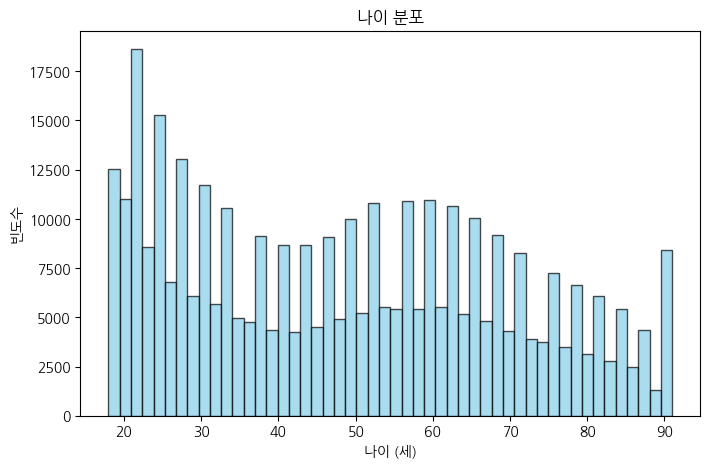

(18, 91)

In [116]:
# 나이 분포 시각화
plt.figure(figsize=(8,5))
plt.hist(df["anchor_age"], bins=50, alpha=0.7, color="skyblue", edgecolor="black")
plt.xlabel("나이 (세)")
plt.ylabel("빈도수")
plt.title("나이 분포")
plt.show()

# 최소값과 최대값 확인
age_min, age_max = df["anchor_age"].min(), df["anchor_age"].max()
age_min, age_max

Insight: 나이는 이상치 없음. 가장 어린게 18살부터 91살까지

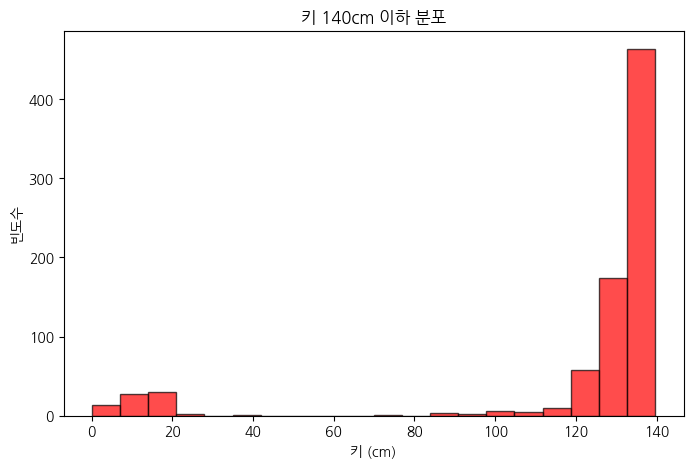

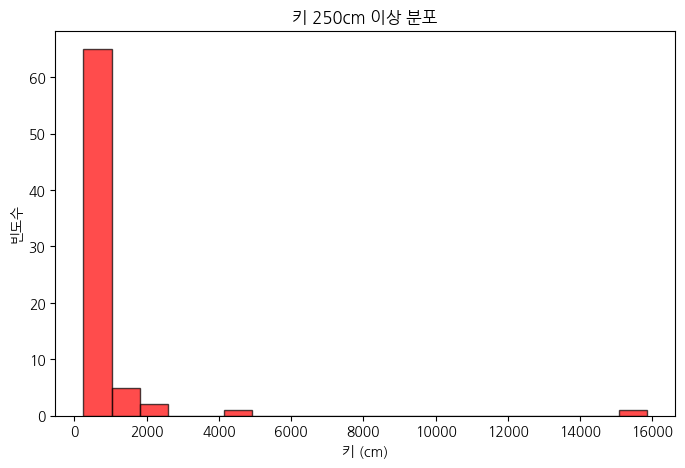

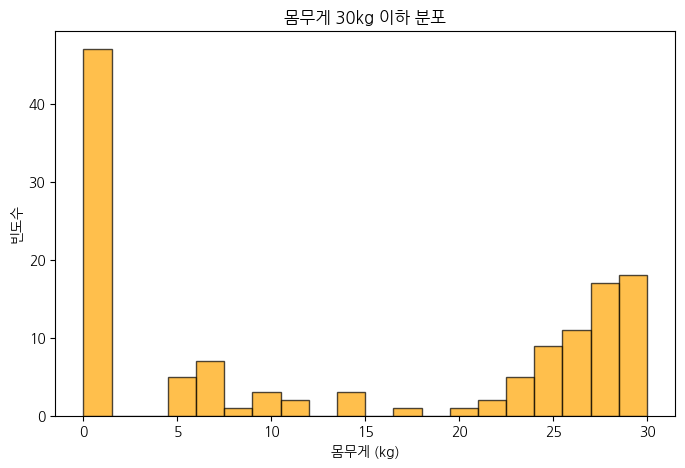

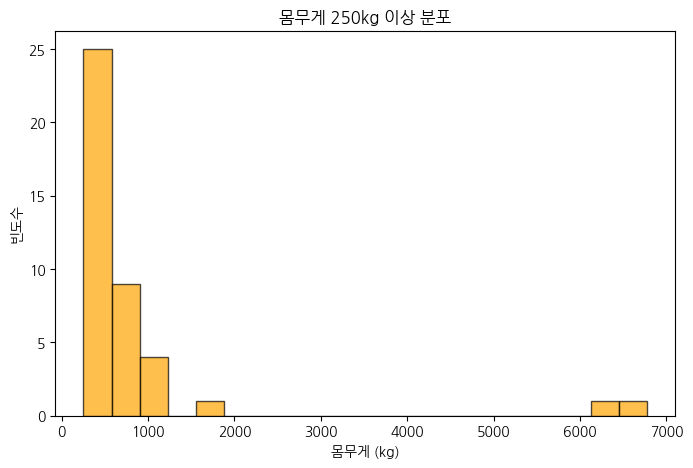

In [117]:
# 키 140 이하 분포
plt.figure(figsize=(8,5))
plt.hist(df[df["height_cm"] <= 140]["height_cm"], bins=20, color="red", alpha=0.7, edgecolor="black")
plt.xlabel("키 (cm)")
plt.ylabel("빈도수")
plt.title("키 140cm 이하 분포")
plt.show()

# 키 250 이상 분포
plt.figure(figsize=(8,5))
plt.hist(df[df["height_cm"] >= 250]["height_cm"], bins=20, color="red", alpha=0.7, edgecolor="black")
plt.xlabel("키 (cm)")
plt.ylabel("빈도수")
plt.title("키 250cm 이상 분포")
plt.show()

# 몸무게 30 이하 분포
plt.figure(figsize=(8,5))
plt.hist(df[df["weight_kg"] <= 30]["weight_kg"], bins=20, color="orange", alpha=0.7, edgecolor="black")
plt.xlabel("몸무게 (kg)")
plt.ylabel("빈도수")
plt.title("몸무게 30kg 이하 분포")
plt.show()

# 몸무게 250 이상 분포
plt.figure(figsize=(8,5))
plt.hist(df[df["weight_kg"] >= 250]["weight_kg"], bins=20, color="orange", alpha=0.7, edgecolor="black")
plt.xlabel("몸무게 (kg)")
plt.ylabel("빈도수")
plt.title("몸무게 250kg 이상 분포")
plt.show()


키(height_cm) 120 이하 또는 250 이상인 행,
몸무게(weight_kg) 25 이하 또는 300 이상인 행
drop

In [118]:
# 🔹 1. 키(height_cm) 120 이하 또는 250 이상인 행
outliers_height = df[(df["height_cm"] <= 120) | (df["height_cm"] >= 250)]
print("키 이상치 개수:", len(outliers_height))

# drop으로 제거 (원본 df에서 삭제)
df = df.drop(outliers_height.index)

# 🔹 2. 몸무게(weight_kg) 25 이하 또는 300 이상인 행
outliers_weight = df[(df["weight_kg"] <= 25) | (df["weight_kg"] >= 300)]
print("몸무게 이상치 개수:", len(outliers_weight))

# drop으로 제거 (원본 df에서 삭제)
df = df.drop(outliers_weight.index)

# 최종 데이터 크기 확인
print("최종 데이터 개수:", len(df))

키 이상치 개수: 182
몸무게 이상치 개수: 107
최종 데이터 개수: 364338


BMI 이상치 제거

In [119]:
# 🔹 BMI 이상치 개수 세기
# (1) 정상 범위 기준
outliers_bmi_range = df[(df["bmi"] < 10) | (df["bmi"] > 60)]
print("BMI 범위 이상치 개수:", len(outliers_bmi_range))

# (2) 계산된 BMI와 차이가 큰 경우 (허용 오차 ±2)
df["bmi_calc"] = df["weight_kg"] / ((df["height_cm"] / 100) ** 2)
outliers_bmi_inconsistent = df[(df["bmi"] - df["bmi_calc"]).abs() > 2]
print("BMI 불일치 이상치 개수:", len(outliers_bmi_inconsistent))

# 두 조건의 이상치 인덱스를 합침 (중복 제거)
bmi_outlier_index = outliers_bmi_range.index.union(outliers_bmi_inconsistent.index)

# 한 번에 drop
df = df.drop(bmi_outlier_index)

print("BMI 이상치 총 제거 개수:", len(bmi_outlier_index))
print("최종 데이터 개수:", len(df))

BMI 범위 이상치 개수: 391
BMI 불일치 이상치 개수: 422
BMI 이상치 총 제거 개수: 787
최종 데이터 개수: 363551


In [120]:
# 🔹 심박수 이상치
outliers_hr = df[(df["heart_rate"] < 30) | (df["heart_rate"] > 200)]
print("심박수 이상치 개수:", len(outliers_hr))

# 제거
# df = df.drop(outliers_hr.index)

# 🔹 산소포화도 이상치
outliers_spo2 = df[(df["spo2"] < 60) | (df["spo2"] > 120)]
print("산소포화도 이상치 개수:", len(outliers_spo2))

# 제거
df = df.drop(outliers_spo2.index)

# 최종 데이터 크기 확인
print("최종 데이터 개수:", len(df))


심박수 이상치 개수: 13
산소포화도 이상치 개수: 76
최종 데이터 개수: 363475


# 키, 몸무게, BMI 결측값 처리


1.   키, 몸무게 모두 nan인데 BMI가 있는 행은 없다
2.   키나 몸무게 하나만 존재하고 BMI가 없는 없는 행은 13,000개 정도로 적은 양이라 drop해주었다(채우는 방향으로도 해봐도 됨)
3. 키, 몸무게, BMI 중 하나만 없는 것은 BMI 계산 법으로 채워주었다

결과: 행 363,475개 ▶ 153,922개



In [121]:
# 키, 몸무게, BMI 컬럼만 추출
subset = ["height_cm", "weight_kg", "bmi"]

# 각 행에서 결측치 아닌 값(존재하는 값)의 개수 세기
non_missing_count = df[subset].notna().sum(axis=1)

# 정확히 하나만 존재하는 행 찾기
one_exist_count = (non_missing_count == 1).sum()

print("키, 몸무게, BMI 중 하나만 존재하는 행의 개수:", one_exist_count)

키, 몸무게, BMI 중 하나만 존재하는 행의 개수: 13548


In [122]:
# 조건 만들기
mask = (
    df["height_cm"].isna() &   # 키가 NaN
    df["weight_kg"].isna() &   # 몸무게가 NaN
    df["bmi"].notna()          # BMI는 존재
)

# 조건을 만족하는 행 개수
count = mask.sum()

print("키와 몸무게는 결측치고 BMI만 있는 행의 개수:", count)

키와 몸무게는 결측치고 BMI만 있는 행의 개수: 0


Insight: 키, 몸무게 둘다 결측치이면 drop 해준다

In [123]:
# 조건 만들기
mask = (
    (df["height_cm"].notna() ^ df["weight_kg"].notna()) &  # 키와 몸무게 중 하나만 존재 (XOR)
    df["bmi"].isna()                                       # BMI는 없음
)

# 조건을 만족하는 행 개수
count = mask.sum()

print("키와 몸무게 중 하나만 존재하고, BMI는 없는 행의 개수:", count)

키와 몸무게 중 하나만 존재하고, BMI는 없는 행의 개수: 13548


Insight: 키, 몸무게 둘중 하나만 존재하고 BMI는 없는 행 -> 만삼천개 데이터 살릴거면 drop X

In [124]:
df_a = df.copy()
df_a.head(3)

,subject_id,gender,anchor_age,height_cm,weight_kg,bmi,heart_rate,spo2,has_hypertension,has_diabetes,has_dyslipidemia,has_thyroid,has_obesity,has_hypercholesterolemia,has_metabolic_disease,bmi_calc
0,10000032,F,52,152.4,42.197664,18.2,96.5,96.3,0,0,0,0,0,0,0,18.168475
1,10000048,F,23,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN
2,10000058,F,33,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN


키, 몸무게 둘중 하나만 존재하고 BMI는 없는 행 drop 해주기

In [125]:
# 조건: 키와 몸무게 중 하나만 존재 (XOR), 그리고 BMI는 NaN
mask = (
    (df_a["height_cm"].notna() ^ df_a["weight_kg"].notna()) &
    df_a["bmi"].isna()
)

# 조건을 만족하는 행 제거
df_a = df_a.drop(df_a[mask].index)

print("원본 행 개수:", df.shape[0])
print("정제 후 행 개수:", df_a.shape[0])

원본 행 개수: 363475
정제 후 행 개수: 349927


키, 몸무게 둘다 결측치인 행 drop해주고 둘중 하나라도 있고 bmi가 있으면 bmi 계산법으로 채워주기

In [126]:
# 2. height_cm, weight_kg가 결측치인 행 제거
df_a = df_a.drop(df_a[(df_a["height_cm"].isna()) & (df_a["weight_kg"].isna())].index)

# 3. 결과 확인
print("원본 데이터 크기:", df.shape)
print("정제된 데이터 크기:", df_a.shape)

원본 데이터 크기: (363475, 16)
정제된 데이터 크기: (152834, 16)


In [127]:
# 키, 몸무게, BMI 중에서 하나만 결측치인 행 개수 계산
subset = ["height_cm", "weight_kg", "bmi"]

# 각 행의 결측치 개수
missing_count = df_a[subset].isnull().sum(axis=1)

# 결측치가 정확히 하나인 행의 개수
one_missing_count = (missing_count == 1).sum()

print("키, 몸무게, BMI 중 하나만 없는 행의 개수:", one_missing_count)

키, 몸무게, BMI 중 하나만 없는 행의 개수: 6352


In [128]:
subset = ["height_cm", "weight_kg", "bmi"]

# 1) 셋 중 정확히 하나만 NaN인 행 마스크
mask_one_missing = df_a[subset].isna().sum(axis=1) == 1

# 2) 각 변수별로 어떤 게 비었는지 마스크
miss_h = mask_one_missing & df_a["height_cm"].isna()
miss_w = mask_one_missing & df_a["weight_kg"].isna()
miss_b = mask_one_missing & df_a["bmi"].isna()

# 3) BMI 공식으로 채우기
# bmi = w / (h/100)^2  → bmi가 비었을 때 채움
df_a.loc[miss_b, "bmi"] = (
    df_a.loc[miss_b, "weight_kg"] / ( (df_a.loc[miss_b, "height_cm"]/100.0) ** 2 )
)

# weight = bmi * (h/100)^2  → 몸무게가 비었을 때 채움
df_a.loc[miss_w, "weight_kg"] = (
    df_a.loc[miss_w, "bmi"] * ( (df_a.loc[miss_w, "height_cm"]/100.0) ** 2 )
)

# height(cm) = sqrt(weight / bmi) * 100  → 키가 비었을 때 채움
df_a.loc[miss_h, "height_cm"] = np.sqrt(
    df_a.loc[miss_h, "weight_kg"] / df_a.loc[miss_h, "bmi"]
) * 100.0

In [129]:
# 키, 몸무게, BMI 중에서 하나만 결측치인 행 개수 계산
subset = ["height_cm", "weight_kg", "bmi"]

# 각 행의 결측치 개수
missing_count = df_a[subset].isnull().sum(axis=1)

# 결측치가 정확히 하나인 행의 개수
one_missing_count = (missing_count == 1).sum()

print("키, 몸무게, BMI 중 하나만 없는 행의 개수:", one_missing_count)

키, 몸무게, BMI 중 하나만 없는 행의 개수: 0


In [130]:
print("키, 몸무게 둘다 없는 행 drop 한 개수:", df_a.shape[0])

키, 몸무게 둘다 없는 행 drop 한 개수: 152834


# 산포도, 심박수 결측값 처리

In [131]:
df_1 = df_a.copy()

산포도랑 심박수 둘중에 하나만 있는 행은 없음

In [132]:
# spo2 값이 있는 행의 개수
count_spo2 = df_a["spo2"].notna().sum()

print("spo2가 있는 행의 개수:", count_spo2)

spo2가 있는 행의 개수: 33385


In [133]:
df_1.to_csv("metabolic_disease_dataset_df_1.csv", index=False)

In [134]:
PATH_OUT = "metabolic_disease_dataset_df_d1_imputed_hr_spo2.csv"

bmi, 키, 몸무게, 성별, 나이, 질병을 기준으로 산포도랑 심박수 예측하기(df_1)

In [135]:
# 2) 타겟(심박수/산소포화도)과 피처 분리
TARGETS = ["heart_rate", "spo2"]  # 심박수, 산소포화도
for c in TARGETS:
    if c not in df_1.columns:
        raise ValueError(f"칼럼 '{c}'이(가) 없습니다. 실제 칼럼들: {list(df_1.columns)}")

# 안전장치: inf 값을 NaN으로
df_1 = df_1.replace([np.inf, -np.inf], np.nan)

X = df_1.drop(columns=TARGETS)
Y = df_1[TARGETS].copy()

# 3) 전처리: 숫자/범주형 분리
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_tf = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # sklearn 버전에 따라 sparse_output이 없을 수 있어요 → sparse=False 사용
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    [("num", numeric_tf, num_cols),
     ("cat", categorical_tf, cat_cols)]
)

# 4) 피처 전처리(결측 간단 대체 + 원-핫 인코딩)
Xp = preprocess.fit_transform(X)

# 편의상 전처리된 피처를 DataFrame으로
def get_feature_names(preprocess, num_cols, cat_cols):
    names = []
    if num_cols:
        names.extend(num_cols)
    if cat_cols:
        ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
        names.extend(ohe.get_feature_names_out(cat_cols).tolist())
    return names

Xp = pd.DataFrame(Xp, columns=get_feature_names(preprocess, num_cols, cat_cols), index=df_1.index)

# 5) MICE(IterativeImputer)용 결합 행렬 구성: [타겟 2개 + 전처리된 피처들]
#    → Imputer가 상호관계를 이용해 타겟의 NaN을 추정
combo = pd.concat([Y, Xp], axis=1)

imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=5,               # 빠르게 돌리려면 3~5, 더 정교하게는 10~20
    sample_posterior=True,    # MICE 특성(사후 샘플링) 반영
    random_state=42,
    n_nearest_features=min(10, combo.shape[1]-1),  # 속도/안정성 균형
    initial_strategy="median",
    tol=1e-3
)

combo_imputed = imputer.fit_transform(combo)
combo_imputed = pd.DataFrame(combo_imputed, columns=combo.columns, index=combo.index)

# 6) 원본 df에 타겟 두 칼럼만 덮어쓰기
df_out = df_a.copy()
df_out["heart_rate"] = combo_imputed["heart_rate"]
df_out["spo2"]       = combo_imputed["spo2"]

# 7) 저장
df_out.to_csv(PATH_OUT, index=False)

# 8) 간단 요약 출력
before = Y
after  = df_out[TARGETS]
summary = pd.DataFrame({
    "column": TARGETS,
    "n_missing_before": [before[c].isna().sum() for c in TARGETS],
    "n_missing_after":  [after[c].isna().sum()  for c in TARGETS],
    "mean_before":      [before[c].mean(skipna=True) for c in TARGETS],
    "mean_after":       [after[c].mean() for c in TARGETS],
    "std_before":       [before[c].std(skipna=True)  for c in TARGETS],
    "std_after":        [after[c].std() for c in TARGETS],
})
print(summary)
print(f"\nSaved: {PATH_OUT}")

       column  n_missing_before  n_missing_after  mean_before  mean_after  \
0  heart_rate            119431                0    84.675041   86.738587   
1        spo2            119449                0    96.506387   96.641892   

   std_before  std_after  
0   67.677603  69.411409  
1    1.954771   1.957014  

Saved: metabolic_disease_dataset_df_d1_imputed_hr_spo2.csv


# MODEL

모델은 xgb, lgb, cat 세 개만 씀\
파라미터튜닝은 optuna\
당뇨 xgb 돌리는 데만 15분 걸림


\
결과
roc_auc 결과는 93로 높지만 precision 34로 낮음
1. 질환 걸린게 확실한 경우만 알려주기
2. 확실하진 않지만 의심될 경우 전부 알려주기
3. roc_auc 결과만 발표하기
=> 이 세 개에 따라서 threshold 임계점 결정하기


결과
xgboost 기준 당뇨

{'roc_auc': 0.9366661725702199, 'pr_auc': 0.5821545208435404, 'f1': 0.5062669822070296, 'precision': 0.342139556924535, 'recall': 0.9730458221024259, 'balanced_accuracy': 0.8859214399834205}

parameters: {'n_estimators': 750, 'max_depth': 6, 'learning_rate': 0.012063831199720407, 'subsample': 0.810043193750127, 'colsample_bytree': 0.9485447650181705, 'min_child_weight': 9, 'reg_alpha': 0.00023202800647354293, 'reg_lambda': 6.435619845363364e-07, 'gamma': 4.529695841499388}

In [ ]:
# -*- coding: utf-8 -*-
# """
# 멀티 라벨(7개 질환) 이진 분류: XGBoost / LightGBM / CatBoost + Optuna 튜닝
# - 데이터: metabolic_disease_dataset_df_d1_imputed_hr_spo2.csv
# - 자동으로 이진 타깃 칼럼을 추정해 기본 7개를 학습합니다. (코드 상단 TARGET_COLUMNS 수정 가능)
# - 결과물:
#     * metrics_summary.csv : 질환×모델 성능 요약
#     * models/<질환>/<모델명>.pkl : 파이프라인(원-핫 인코더 + 모델) 저장 (joblib)
#     * models/<질환>/<모델명>_best_params.json : 최적 하이퍼파라미터
# """

# ====== 사용자 설정 ======
RANDOM_STATE = 42
N_TRIALS = 25             # 각 모델당 Optuna 시도 횟수
N_SPLITS = 4              # 교차검증 폴드 수
TEST_SIZE = 0.2

# 자동 추정된 기본 타깃(7개). 필요시 직접 수정하세요.
TARGET_COLUMNS_ONLY_ONE = [
  "has_diabetes",
  # "has_dyslipidemia",
  # "has_hypercholesterolemia",
  # "has_hypertension",
  # "has_metabolic_disease",
  # "has_obesity",
  # "has_thyroid"
]

TARGET_COLUMNS = [
  "has_diabetes",
  "has_dyslipidemia",
  "has_hypercholesterolemia",
  "has_hypertension",
  "has_metabolic_disease",
  "has_obesity",
  "has_thyroid"
]


# ----- 피처/타깃 분리 -----
def get_feature_target(df_1, target_col):
    X = df_1.drop(columns=[target_col])
    y = df_1[target_col].astype(int)  # 이진 가정
    return X, y

# ----- 컬럼 타입 식별 -----
def split_feature_types(df_1):
    cat_cols = [c for c in df_1.columns if df[c].dtype == "object" or str(df[c].dtype).startswith("category")]
    num_cols = [c for c in df_1.columns if c not in cat_cols]
    return num_cols, cat_cols

# ----- OneHotEncoder 버전 호환 -----
def make_ohe():
    if version.parse(sklearn_version) >= version.parse("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# ----- 공통 전처리 파이프라인 -----
def build_preprocessor(X):
    num_cols, cat_cols = split_feature_types(X)
    transformers = []
    if num_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), num_cols))
    if cat_cols:
        from sklearn.pipeline import Pipeline as SkPipeline
        transformers.append(("cat", SkPipeline([("imp", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())]), cat_cols))
    if transformers:
        pre = ColumnTransformer(transformers)
    else:
        # 전처리할 것이 없으면 식별 변환
        from sklearn.preprocessing import FunctionTransformer
        pre = ColumnTransformer([("identity", FunctionTransformer(lambda x: x), X.columns.tolist())])
    return pre

# ----- 점수 함수 (AUC 우선) -----
def cv_auc(pipeline, X, y, n_splits):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    try:
        scores = cross_val_score(pipeline, X, y, scoring="roc_auc", cv=skf, n_jobs=-1, error_score="raise")
    except Exception:
        # 클래스 불균형 등으로 오류나는 경우 accuracy로 대체
        scores = cross_val_score(pipeline, X, y, scoring="balanced_accuracy", cv=skf, n_jobs=-1)
    return float(np.mean(scores))

# ----- 모델별 Optuna 탐색 공간 -----
def suggest_xgb(trial, scale_pos_weight):
    return XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 1200),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        n_jobs=-1,
        random_state=42,
        tree_method="hist",
        eval_metric="logloss",
        verbosity=0,
    )

def suggest_lgbm(trial, scale_pos_weight):
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    return LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 1200),
        num_leaves=trial.suggest_int("num_leaves", 15, 255),
        max_depth=trial.suggest_int("max_depth", -1, 12),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 120),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        min_split_gain=trial.suggest_float("min_split_gain", 0.0, 1.0),
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1,
        objective="binary",
        verbose=-1,
    )

def suggest_cat(trial, scale_pos_weight):
    return CatBoostClassifier(
        iterations=trial.suggest_int("iterations", 400, 1500),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 2.0),
        border_count=trial.suggest_int("border_count", 32, 255),
        loss_function="Logloss",
        eval_metric="AUC",
        random_state=42,
        thread_count=-1,
        task_type="CPU",
        verbose=False,
        scale_pos_weight=scale_pos_weight
    )

# ----- 단일 타깃 + 단일 모델 튜닝/학습/평가 -----
def tune_and_train_one(X, y, model_name, n_trials, n_splits):
    # 불균형 보정 계수(고정)
    pos = max(1, int((y == 1).sum()))
    neg = max(1, int((y == 0).sum()))
    spw = float(neg / pos)

    pre = build_preprocessor(X)

    def build_model(trial):
        if model_name == "xgboost":
            model = suggest_xgb(trial, spw)
        elif model_name == "lightgbm":
            model = suggest_lgbm(trial, spw)
        elif model_name == "catboost":
            model = suggest_cat(trial, spw)
        else:
            raise ValueError("unknown model")
        return Pipeline([("pre", pre), ("clf", model)])

    def objective(trial):
        pipe = build_model(trial)
        return cv_auc(pipe, X, y, n_splits)

    study = optuna.create_study(direction="maximize", study_name=f"{model_name}_study", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, n_jobs=1, show_progress_bar=False)

    # 최적 파이프라인 학습 (train/test split으로 최종 성능 산출)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=42)
    best_pipe = build_model(study.best_trial)
    best_pipe.fit(X_tr, y_tr)

    # 평가
    proba = best_pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)

    metrics = {
        "roc_auc": float(roc_auc_score(y_te, proba)) if len(np.unique(y_te)) > 1 else np.nan,
        "pr_auc": float(average_precision_score(y_te, proba)) if len(np.unique(y_te)) > 1 else np.nan,
        "f1": float(f1_score(y_te, pred, zero_division=0)),
        "precision": float(precision_score(y_te, pred, zero_division=0)),
        "recall": float(recall_score(y_te, pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_te, pred)),
    }

    return best_pipe, study.best_params, metrics

def main():
    results = []
    models = ["xgboost"] #models = ["xgboost", "lightgbm", "catboost"]

    out_dir = Path("models")
    out_dir.mkdir(parents=True, exist_ok=True)

    for target in TARGET_COLUMNS_ONLY_ONE:
        print(f"\n===== Target: {target} =====")
        X, y = get_feature_target(df_1, target)

        for model_name in models:
            print(f"--- Model: {model_name} (Optuna trials={N_TRIALS}) ---")
            pipe, best_params, metrics = tune_and_train_one(X, y, model_name, N_TRIALS, N_SPLITS)

            # 저장
            tdir = out_dir / target
            tdir.mkdir(parents=True, exist_ok=True)

            model_path = tdir / f"{model_name}.pkl"
            params_path = tdir / f"{model_name}_best_params.json"

            joblib.dump(pipe, model_path)
            with open(params_path, "w", encoding="utf-8") as f:
                json.dump(best_params, f, ensure_ascii=False, indent=2)

            row = {"target": target, "model": model_name}
            row.update(metrics)
            results.append(row)

            print(f"Saved: {model_path}\nMetrics: {metrics}\nBest params keys: {list(best_params.keys())}")

    # 요약 저장
    summary = pd.DataFrame(results)
    summary_path = Path("metrics_summary.csv")
    summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
    print(f"\n=== Summary saved to {summary_path.resolve()} ===")
    # 각 타깃별 최고 모델 출력
    try:
        idx = summary.groupby("target")["roc_auc"].idxmax()
        print("\nBest by target (ROC AUC):")
        print(summary.loc[idx].sort_values(["target"]).to_string(index=False))
    except Exception:
        pass

if __name__ == "__main__":
    main()


[I 2025-08-17 21:23:42,661] A new study created in memory with name: xgboost_study



===== Target: has_diabetes =====
--- Model: xgboost (Optuna trials=25) ---


[I 2025-08-17 21:24:09,944] Trial 0 finished with value: 0.9280082413357073 and parameters: {'n_estimators': 574, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.9280082413357073.
[I 2025-08-17 21:24:30,939] Trial 1 finished with value: 0.9285846219459909 and parameters: {'n_estimators': 908, 'max_depth': 3, 'learning_rate': 0.2526878207508456, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 0.9285846219459909.
[I 2025-08-17 21:24:54,875] Trial 2 finished with value: 0.9334858032265384 and parameters: {'n_estimators': 632, 'max_depth': 5, 'learning_rate': 0.032781876533976156, 'su

Saved: models/has_diabetes/xgboost.pkl
Metrics: {'roc_auc': 0.9366661725702199, 'pr_auc': 0.5821545208435404, 'f1': 0.5062669822070296, 'precision': 0.342139556924535, 'recall': 0.9730458221024259, 'balanced_accuracy': 0.8859214399834205}
Best params keys: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree', 'min_child_weight', 'reg_alpha', 'reg_lambda', 'gamma']
--- Model: lightgbm (Optuna trials=25) ---


[I 2025-08-17 21:40:59,216] Trial 0 finished with value: 0.9110285286122722 and parameters: {'class_weight': 'balanced', 'n_estimators': 932, 'num_leaves': 159, 'max_depth': 1, 'learning_rate': 0.0024345423962016913, 'min_child_samples': 11, 'subsample': 0.9330880728874675, 'colsample_bytree': 0.8005575058716043, 'reg_alpha': 0.023585940584142682, 'reg_lambda': 1.5320059381854043e-08, 'min_split_gain': 0.9699098521619943}. Best is trial 0 with value: 0.9110285286122722.
[I 2025-08-17 21:42:14,696] Trial 1 finished with value: 0.924467322367033 and parameters: {'class_weight': None, 'n_estimators': 382, 'num_leaves': 59, 'max_depth': 3, 'learning_rate': 0.0199473547030745, 'min_child_samples': 55, 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'reg_alpha': 1.8007140198129195e-07, 'reg_lambda': 4.258943089524393e-06, 'min_split_gain': 0.3663618432936917}. Best is trial 1 with value: 0.924467322367033.
[I 2025-08-17 21:44:42,801] Trial 2 finished with value: 0.921